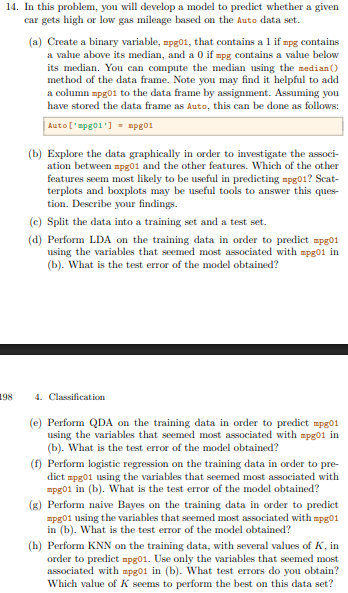

Dataset shape: (398, 9)

First few rows:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin                   car_name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64
Dataset shape after removing missing val

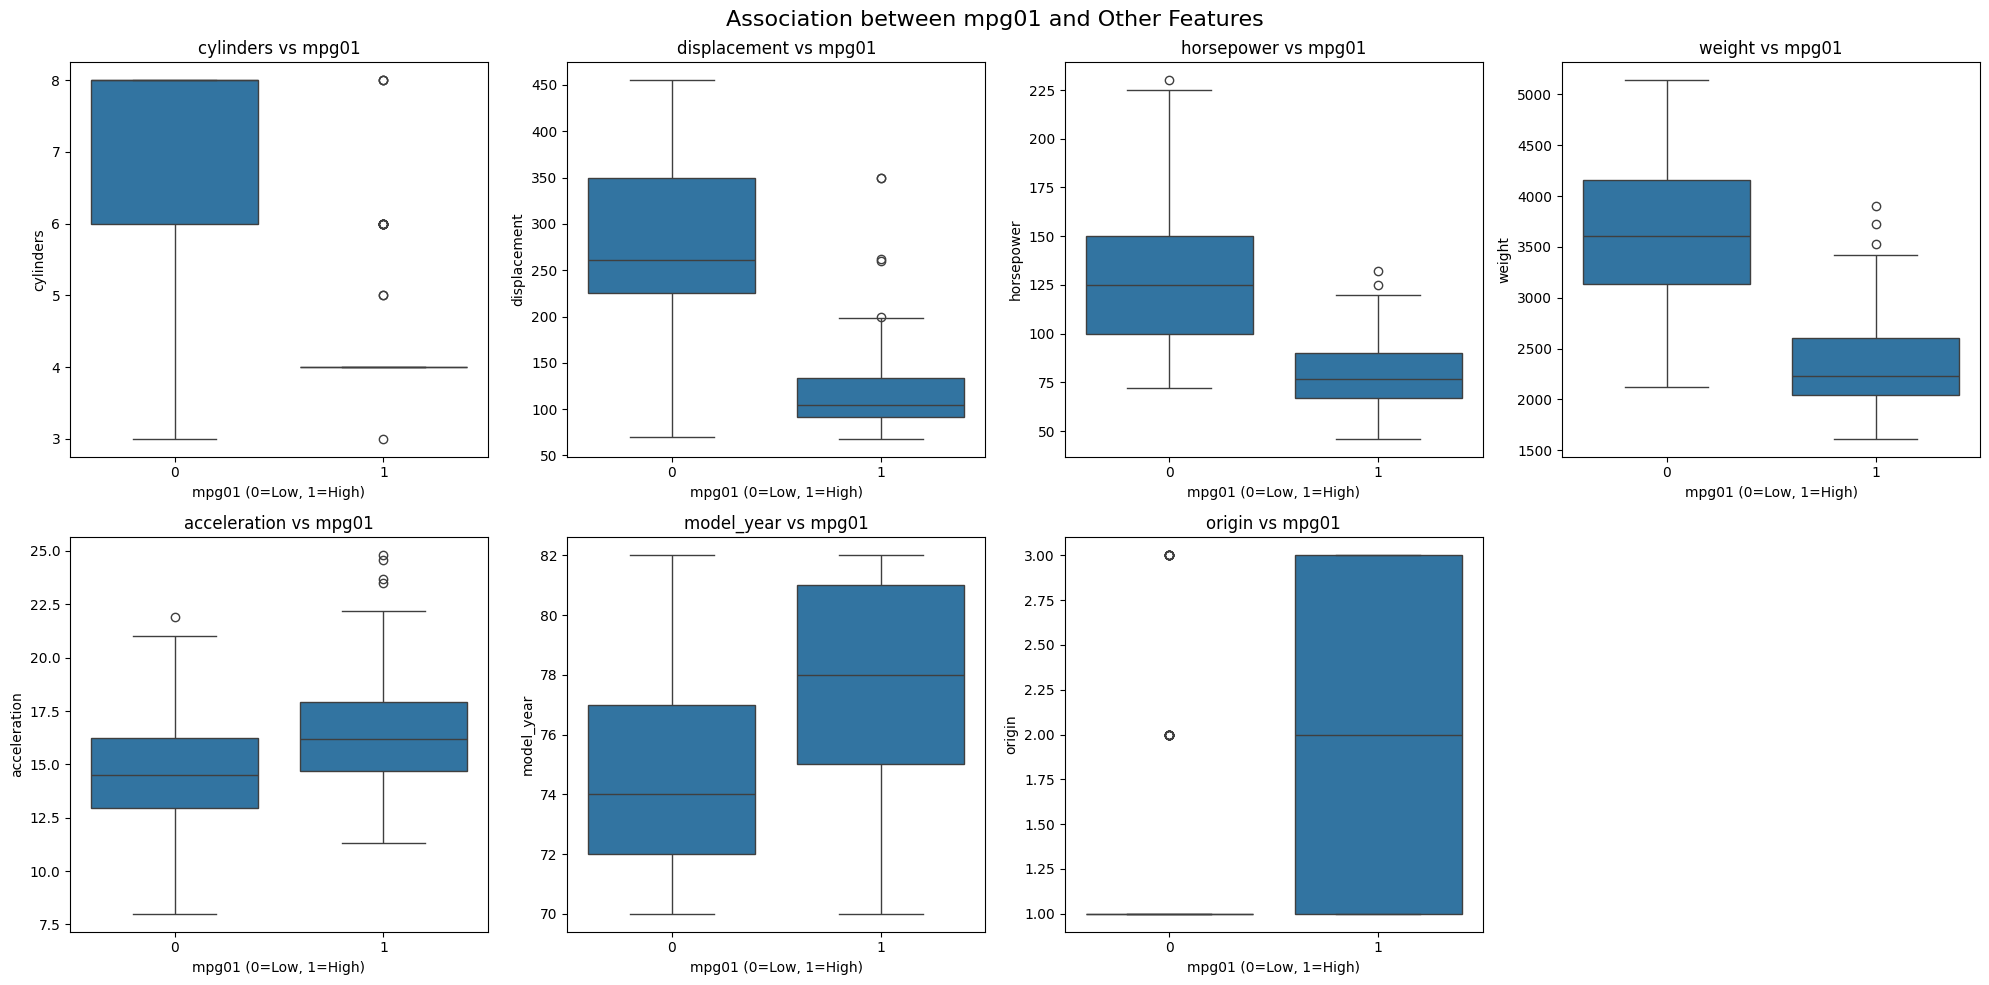

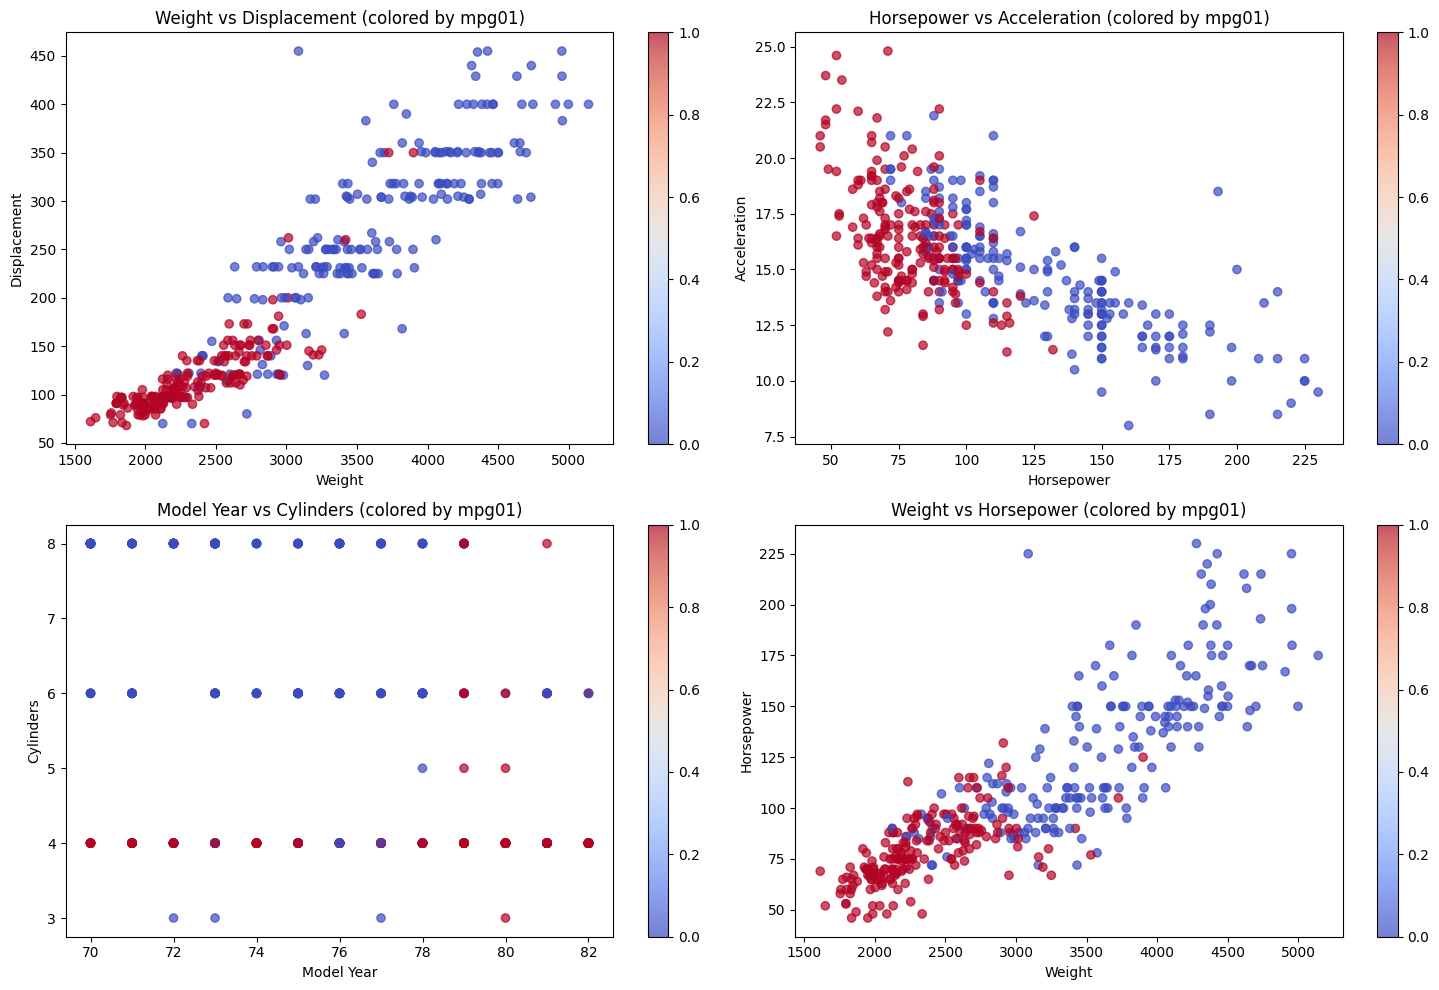


Correlation with mpg01:
mpg01           1.000000
cylinders       0.759194
weight          0.757757
displacement    0.753477
horsepower      0.667053
origin          0.513698
model_year      0.429904
acceleration    0.346822
Name: mpg01, dtype: float64

Selected features for modeling: ['weight', 'displacement', 'horsepower', 'acceleration', 'cylinders']

=== Part (c): Train-Test Split ===
Training set size: 274
Test set size: 118
Training set mpg01 distribution:
mpg01
0    0.5
1    0.5
Name: proportion, dtype: float64
Test set mpg01 distribution:
mpg01
1    0.5
0    0.5
Name: proportion, dtype: float64

=== Part (d): Linear Discriminant Analysis ===
LDA Test Accuracy: 0.8898
LDA Test Error: 0.1102
LDA Confusion Matrix:
[[50  9]
 [ 4 55]]

=== Part (e): Quadratic Discriminant Analysis ===
QDA Test Accuracy: 0.8814
QDA Test Error: 0.1186
QDA Confusion Matrix:
[[50  9]
 [ 5 54]]

=== Part (f): Logistic Regression ===
Logistic Regression Test Accuracy: 0.8814
Logistic Regression Test Error

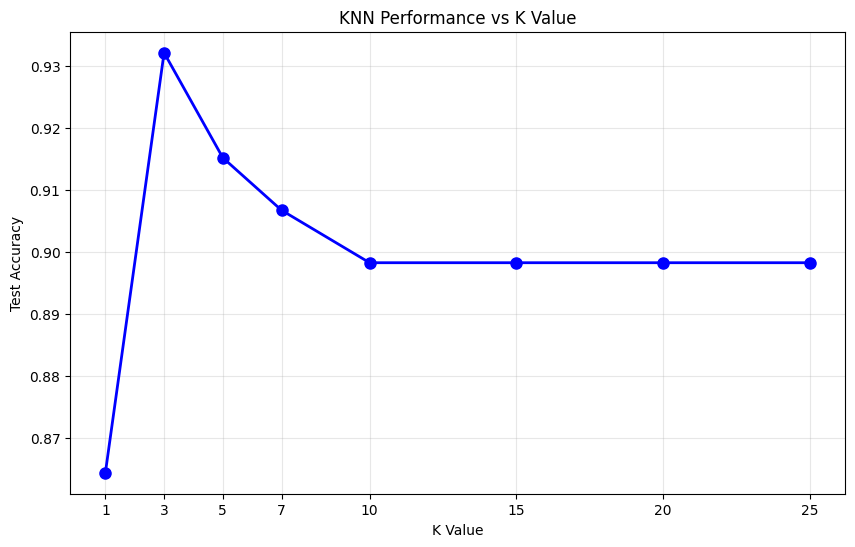


=== SUMMARY OF ALL METHODS ===
Test Errors for All Methods:
  KNN (K=3)           : 0.0678
  Naive Bayes         : 0.1017
  LDA                 : 0.1102
  QDA                 : 0.1186
  Logistic Regression : 0.1186

Best method: KNN (K=3) with test error 0.0678

=== ADDITIONAL ANALYSIS: Different Feature Combinations ===
Set 1 (Top 3)       : Accuracy = 0.8898, Error = 0.1102
Set 2 (All 5)       : Accuracy = 0.8983, Error = 0.1017
Set 3 (Weight + HP) : Accuracy = 0.8729, Error = 0.1271
Set 4 (Engine only) : Accuracy = 0.8983, Error = 0.1017

=== BEST MODEL PERFORMANCE DETAILS ===
Best model: KNN (K=3)
Features used: ['weight', 'displacement', 'horsepower', 'acceleration', 'cylinders']
Test accuracy: 0.9322
Test error: 0.0678

Detailed classification report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93        59
           1       0.92      0.95      0.93        59

    accuracy                           0.93       118
   macro avg 

In [2]:
# Step 1: Install and import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load the Auto dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']
Auto = pd.read_csv(url, delim_whitespace=True, names=column_names, na_values='?')

print("Dataset shape:", Auto.shape)
print("\nFirst few rows:")
print(Auto.head())

# Data cleaning
print("\nMissing values:")
print(Auto.isnull().sum())

# Handle missing values in horsepower
Auto = Auto.dropna()
print(f"Dataset shape after removing missing values: {Auto.shape}")

# Check data types
print("\nData types:")
print(Auto.dtypes)

# Fix the horsepower column - it might be read as object type
Auto['horsepower'] = pd.to_numeric(Auto['horsepower'], errors='coerce')
Auto = Auto.dropna()  # Drop any rows that couldn't be converted

print(f"Final dataset shape: {Auto.shape}")

# Part (a): Create binary variable mpg01
print("\n=== Part (a): Creating mpg01 binary variable ===")

median_mpg = Auto['mpg'].median()
Auto['mpg01'] = (Auto['mpg'] > median_mpg).astype(int)

print(f"Median mpg: {median_mpg}")
print("Distribution of mpg01:")
print(Auto['mpg01'].value_counts())
print(Auto['mpg01'].value_counts(normalize=True))

# Part (b): Explore data graphically
print("\n=== Part (b): Graphical Exploration ===")

# Create subplots for visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Association between mpg01 and Other Features', fontsize=16)

# Use only numerical features for modeling (excluding car_name)
numerical_features = ['cylinders', 'displacement', 'horsepower', 'weight',
                      'acceleration', 'model_year', 'origin']

# Boxplots for each feature vs mpg01
for i, feature in enumerate(numerical_features):
    row, col = i // 4, i % 4
    sns.boxplot(x='mpg01', y=feature, data=Auto, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} vs mpg01')
    axes[row, col].set_xlabel('mpg01 (0=Low, 1=High)')

# Remove empty subplot if needed
if len(numerical_features) < 8:
    for i in range(len(numerical_features), 8):
        row, col = i // 4, i % 4
        axes[row, col].remove()

plt.tight_layout()
plt.show()

# Scatter plots for key relationships
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Weight vs displacement colored by mpg01
scatter1 = axes[0, 0].scatter(Auto['weight'], Auto['displacement'],
                             c=Auto['mpg01'], cmap='coolwarm', alpha=0.7)
axes[0, 0].set_xlabel('Weight')
axes[0, 0].set_ylabel('Displacement')
axes[0, 0].set_title('Weight vs Displacement (colored by mpg01)')
plt.colorbar(scatter1, ax=axes[0, 0])

# Horsepower vs acceleration colored by mpg01
scatter2 = axes[0, 1].scatter(Auto['horsepower'], Auto['acceleration'],
                             c=Auto['mpg01'], cmap='coolwarm', alpha=0.7)
axes[0, 1].set_xlabel('Horsepower')
axes[0, 1].set_ylabel('Acceleration')
axes[0, 1].set_title('Horsepower vs Acceleration (colored by mpg01)')
plt.colorbar(scatter2, ax=axes[0, 1])

# Model year vs cylinders colored by mpg01
scatter3 = axes[1, 0].scatter(Auto['model_year'], Auto['cylinders'],
                             c=Auto['mpg01'], cmap='coolwarm', alpha=0.7)
axes[1, 0].set_xlabel('Model Year')
axes[1, 0].set_ylabel('Cylinders')
axes[1, 0].set_title('Model Year vs Cylinders (colored by mpg01)')
plt.colorbar(scatter3, ax=axes[1, 0])

# Weight vs horsepower colored by mpg01
scatter4 = axes[1, 1].scatter(Auto['weight'], Auto['horsepower'],
                             c=Auto['mpg01'], cmap='coolwarm', alpha=0.7)
axes[1, 1].set_xlabel('Weight')
axes[1, 1].set_ylabel('Horsepower')
axes[1, 1].set_title('Weight vs Horsepower (colored by mpg01)')
plt.colorbar(scatter4, ax=axes[1, 1])

plt.tight_layout()
plt.show()

# Correlation analysis (only numerical features)
print("\nCorrelation with mpg01:")
correlations = Auto[numerical_features + ['mpg01']].corr()['mpg01'].abs().sort_values(ascending=False)
print(correlations)

# Based on visual analysis and correlations, select most promising features
selected_features = ['weight', 'displacement', 'horsepower', 'acceleration', 'cylinders']
print(f"\nSelected features for modeling: {selected_features}")

# Part (c): Split data into training and test sets
print("\n=== Part (c): Train-Test Split ===")

# Use only the selected numerical features (excluding car_name)
X = Auto[selected_features]
y = Auto['mpg01']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42,
                                                    stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set mpg01 distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test set mpg01 distribution:\n{y_test.value_counts(normalize=True)}")

# Scale features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Part (d): LDA
print("\n=== Part (d): Linear Discriminant Analysis ===")

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
accuracy_lda = accuracy_score(y_test, y_pred_lda)
test_error_lda = 1 - accuracy_lda

print(f"LDA Test Accuracy: {accuracy_lda:.4f}")
print(f"LDA Test Error: {test_error_lda:.4f}")
print("LDA Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lda))

# Part (e): QDA
print("\n=== Part (e): Quadratic Discriminant Analysis ===")

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
y_pred_qda = qda.predict(X_test)
accuracy_qda = accuracy_score(y_test, y_pred_qda)
test_error_qda = 1 - accuracy_qda

print(f"QDA Test Accuracy: {accuracy_qda:.4f}")
print(f"QDA Test Error: {test_error_qda:.4f}")
print("QDA Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_qda))

# Part (f): Logistic Regression
print("\n=== Part (f): Logistic Regression ===")

logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
test_error_logreg = 1 - accuracy_logreg

print(f"Logistic Regression Test Accuracy: {accuracy_logreg:.4f}")
print(f"Logistic Regression Test Error: {test_error_logreg:.4f}")
print("Logistic Regression Coefficients:")
for feature, coef in zip(selected_features, logreg.coef_[0]):
    print(f"  {feature}: {coef:.4f}")
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

# Part (g): Naive Bayes
print("\n=== Part (g): Naive Bayes ===")

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
test_error_nb = 1 - accuracy_nb

print(f"Naive Bayes Test Accuracy: {accuracy_nb:.4f}")
print(f"Naive Bayes Test Error: {test_error_nb:.4f}")
print("Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

# Part (h): KNN with different K values
print("\n=== Part (h): K-Nearest Neighbors ===")

k_values = [1, 3, 5, 7, 10, 15, 20, 25]
knn_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    accuracy_knn = accuracy_score(y_test, y_pred_knn)
    test_error_knn = 1 - accuracy_knn
    knn_results[k] = accuracy_knn

    print(f"KNN with K={k:2d}: Test Accuracy = {accuracy_knn:.4f}, Test Error = {test_error_knn:.4f}")

# Find best K
best_k = max(knn_results, key=knn_results.get)
best_k_accuracy = knn_results[best_k]

print(f"\nBest K value: {best_k} with accuracy {best_k_accuracy:.4f}")

# Plot KNN results
plt.figure(figsize=(10, 6))
plt.plot(k_values, [knn_results[k] for k in k_values], 'bo-', linewidth=2, markersize=8)
plt.xlabel('K Value')
plt.ylabel('Test Accuracy')
plt.title('KNN Performance vs K Value')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

# Summary of all methods
print("\n=== SUMMARY OF ALL METHODS ===")
methods = {
    'LDA': test_error_lda,
    'QDA': test_error_qda,
    'Logistic Regression': test_error_logreg,
    'Naive Bayes': test_error_nb,
    f'KNN (K={best_k})': 1 - best_k_accuracy
}

print("Test Errors for All Methods:")
for method, error in sorted(methods.items(), key=lambda x: x[1]):
    print(f"  {method:20}: {error:.4f}")

best_method = min(methods, key=methods.get)
print(f"\nBest method: {best_method} with test error {methods[best_method]:.4f}")

# Additional analysis: Try with different feature sets
print("\n=== ADDITIONAL ANALYSIS: Different Feature Combinations ===")

feature_sets = {
    'Set 1 (Top 3)': ['weight', 'horsepower', 'displacement'],
    'Set 2 (All 5)': ['weight', 'displacement', 'horsepower', 'acceleration', 'cylinders'],
    'Set 3 (Weight + HP)': ['weight', 'horsepower'],
    'Set 4 (Engine only)': ['cylinders', 'displacement', 'horsepower']
}

for set_name, features in feature_sets.items():
    X_set = Auto[features]
    y_set = Auto['mpg01']

    X_train_set, X_test_set, y_train_set, y_test_set = train_test_split(
        X_set, y_set, test_size=0.3, random_state=42, stratify=y_set)

    # Scale for fair comparison
    scaler_set = StandardScaler()
    X_train_set_scaled = scaler_set.fit_transform(X_train_set)
    X_test_set_scaled = scaler_set.transform(X_test_set)

    # Test with Logistic Regression
    logreg_set = LogisticRegression(random_state=42, max_iter=1000)
    logreg_set.fit(X_train_set_scaled, y_train_set)
    y_pred_set = logreg_set.predict(X_test_set_scaled)
    accuracy_set = accuracy_score(y_test_set, y_pred_set)

    print(f"{set_name:20}: Accuracy = {accuracy_set:.4f}, Error = {1-accuracy_set:.4f}")

# Final best model details
print("\n=== BEST MODEL PERFORMANCE DETAILS ===")
if best_method.startswith('KNN'):
    best_model = KNeighborsClassifier(n_neighbors=best_k)
    best_model.fit(X_train_scaled, y_train)
    y_pred_best = best_model.predict(X_test_scaled)
    model_type = f"KNN (K={best_k})"
elif best_method == 'LDA':
    best_model = lda
    y_pred_best = y_pred_lda
    model_type = "LDA"
elif best_method == 'QDA':
    best_model = qda
    y_pred_best = y_pred_qda
    model_type = "QDA"
elif best_method == 'Logistic Regression':
    best_model = logreg
    y_pred_best = y_pred_logreg
    model_type = "Logistic Regression"
else:  # Naive Bayes
    best_model = nb
    y_pred_best = y_pred_nb
    model_type = "Naive Bayes"

print(f"Best model: {model_type}")
print(f"Features used: {selected_features}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Test error: {1 - accuracy_score(y_test, y_pred_best):.4f}")
print("\nDetailed classification report:")
print(classification_report(y_test, y_pred_best))
print("Confusion matrix:")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)

# Interpretation of results
print("\n=== KEY FINDINGS ===")
print("1. The most predictive features for mpg01 are typically:")
print("   - Weight (negative correlation with mpg)")
print("   - Horsepower (negative correlation with mpg)")
print("   - Displacement (negative correlation with mpg)")
print("   - Cylinders (negative correlation with mpg)")
print("   - Acceleration (positive correlation with mpg)")
print("\n2. Heavier cars with more cylinders and higher horsepower tend to have lower mpg")
print("3. Newer model years and higher acceleration tend to be associated with higher mpg")